# 04 - Create CT series mosaics

Create one compact PNG mosaic per CT series. Each mosaic samples slices evenly across the ordered volume, resizes them to fixed tiles, and arranges them into a square image.

This notebook first previews the original full-frame mosaic behavior so the black background problem is visible. Then it generates the final cropped mosaics used by the pipeline. The reusable logic lives in `scripts/create_series_mosaics.py`.

## 1. Paths and imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SCRIPTS_DIR = REPO_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import create_series_mosaics as mosaics

SERIES_CSV = REPO_ROOT / "outputs" / "sample_series_summary.csv"
DICOM_ROOT = REPO_ROOT / "data" / "extracted"
MOSAIC_DIR = REPO_ROOT / "data" / "mosaics"
MANIFEST_CSV = REPO_ROOT / "outputs" / "mosaic_manifest.csv"
GRID_SIZE = 4
TILE_SIZE = 128

print("series summary:", SERIES_CSV)
print("dicom root    :", DICOM_ROOT)
print("mosaic dir    :", MOSAIC_DIR)
print("manifest      :", MANIFEST_CSV)

series summary: /Users/lucaspu/HelperV1/outputs/sample_series_summary.csv
dicom root    : /Users/lucaspu/HelperV1/data/extracted
mosaic dir    : /Users/lucaspu/HelperV1/data/mosaics
manifest      : /Users/lucaspu/HelperV1/outputs/mosaic_manifest.csv


## 2. Preview original full-frame mosaics

This preview uses the original behavior: each sampled CT slice is resized as a full DICOM frame. The black background remains part of every tile, so a lot of the mosaic can be empty space.

These images are only displayed in memory. They are not saved to `data/mosaics/`.

In [2]:
series_df = pd.read_csv(SERIES_CSV)
ct_df = series_df[series_df["Modality"].astype(str).str.upper() == "CT"].copy()
preview_rows = []

for _, series in ct_df.iterrows():
    series_uid = str(series["SeriesInstanceUID"])
    files = mosaics.collect_series_files(series_uid, DICOM_ROOT)
    sampled = mosaics.sample_evenly(files, GRID_SIZE * GRID_SIZE)
    body_region = mosaics.infer_body_region(series)
    contrast_usage = mosaics.infer_contrast_usage(series)
    image = mosaics.make_mosaic(
        sampled,
        body_region=body_region,
        grid_size=GRID_SIZE,
        tile_size=TILE_SIZE,
        crop_content=False,
    )
    preview_rows.append({
        "SeriesInstanceUID": series_uid,
        "body_region": body_region,
        "contrast_usage": contrast_usage,
        "number_of_files": len(files),
        "sampled_slice_count": len(sampled),
        "image": image,
    })

print(f"Prepared {len(preview_rows)} original full-frame previews")

Prepared 5 original full-frame previews


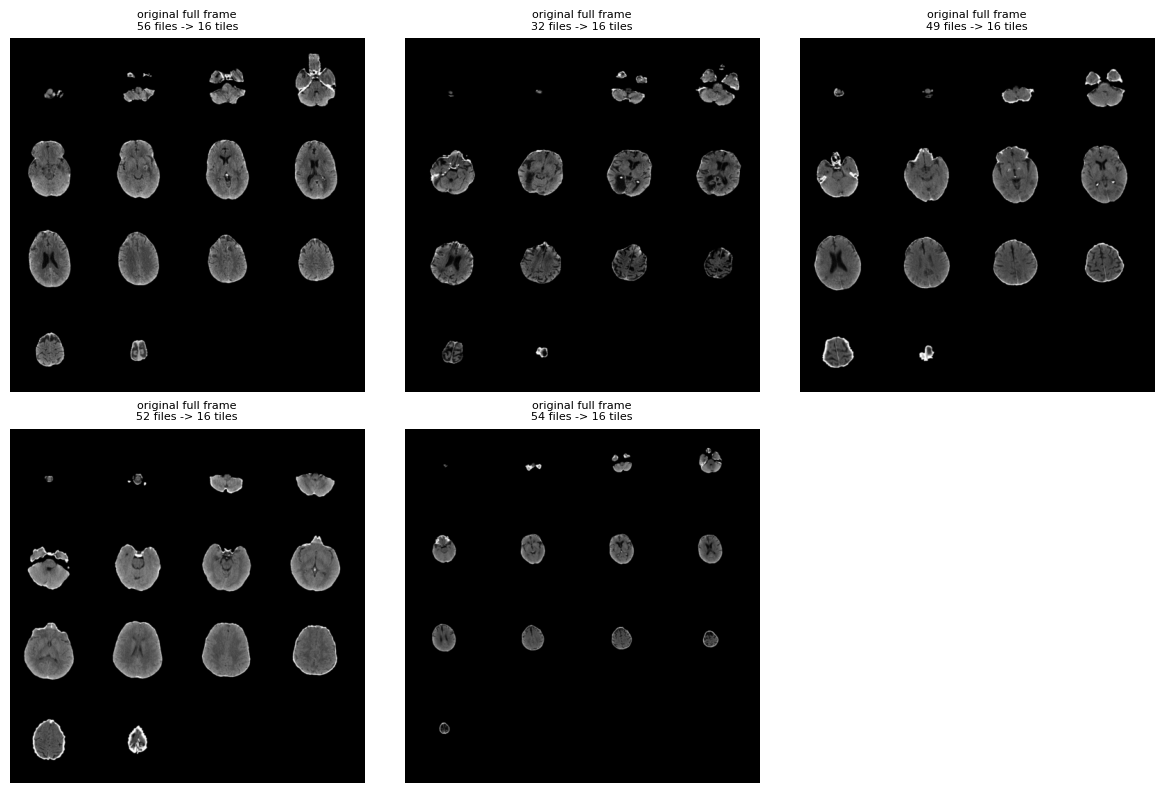

In [3]:
n = len(preview_rows)
cols = min(n, 3)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = [axes] if n == 1 else list(getattr(axes, "flat", [axes]))

for ax, row in zip(axes, preview_rows):
    ax.imshow(row["image"], cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"original full frame\n"
        f"{row['number_of_files']} files -> {row['sampled_slice_count']} tiles",
        fontsize=8,
    )

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 3. Crop black background before resizing

The final pipeline output is still a derived image, not the original DICOM slice. For each sampled slice, the script applies CT windowing, crops away empty black background, resizes the remaining content into a fixed tile, and then places the tile into the mosaic.

This keeps the output size the same (`512 x 512` by default), but gives the anatomy more pixels inside each tile.

In [4]:
manifest = mosaics.create_mosaics(
    input_csv=SERIES_CSV,
    dicom_root=DICOM_ROOT,
    output_dir=MOSAIC_DIR,
    manifest_path=MANIFEST_CSV,
    grid_size=GRID_SIZE,
    tile_size=TILE_SIZE,
    crop_content=True,
)

print(f"Generated {len(manifest)} cropped CT mosaics")
manifest

Generated 5 cropped CT mosaics


,SeriesInstanceUID,StudyInstanceUID,source_class,body_region,contrast_usage,modality,number_of_files,sampled_slice_count,sample_trim_fraction,grid_size,tile_size,mosaic_width,mosaic_height,mosaic_path
0,2.16.840.1.114362.1.12177026.25874454649.63540...,2.16.840.1.114274.1818.51427149410218196123597...,head_ct,head,without_contrast,CT,56,16,0.1,4,128,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
1,2.16.840.1.114362.1.12177026.25874454649.63599...,2.16.840.1.114274.1818.47875515012030584817638...,head_ct,head,without_contrast,CT,32,16,0.1,4,128,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
2,2.16.840.1.114362.1.12177026.25874454649.63630...,2.16.840.1.114274.1818.53399054345234663611660...,head_ct,head,without_contrast,CT,49,16,0.1,4,128,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
3,2.16.840.1.114362.1.12177026.25874454649.63677...,2.16.840.1.114274.1818.47534219802929417114523...,head_ct,head,without_contrast,CT,52,16,0.1,4,128,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
4,2.16.840.1.114362.1.12177026.25874454649.63773...,2.16.840.1.114274.1818.50293343243290883761489...,head_ct,head,without_contrast,CT,54,16,0.1,4,128,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...


## 4. Manifest QA

In [5]:
manifest = pd.read_csv(MANIFEST_CSV)

print("rows:", len(manifest))
print("\nbody_region counts:")
print(manifest["body_region"].value_counts(dropna=False).to_string())
print("\ncontrast_usage counts:")
print(manifest["contrast_usage"].value_counts(dropna=False).to_string())
print("\nsampled_slice_count counts:")
print(manifest["sampled_slice_count"].value_counts(dropna=False).to_string())

manifest[[
    "source_class",
    "body_region",
    "contrast_usage",
    "number_of_files",
    "sampled_slice_count",
    "mosaic_width",
    "mosaic_height",
    "mosaic_path",
]]


rows: 5

body_region counts:
body_region
head    5

contrast_usage counts:
contrast_usage
without_contrast    5

sampled_slice_count counts:
sampled_slice_count
16    5


,source_class,body_region,contrast_usage,number_of_files,sampled_slice_count,mosaic_width,mosaic_height,mosaic_path
0,head_ct,head,without_contrast,56,16,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
1,head_ct,head,without_contrast,32,16,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
2,head_ct,head,without_contrast,49,16,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
3,head_ct,head,without_contrast,52,16,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...
4,head_ct,head,without_contrast,54,16,512,512,data/mosaics/2.16.840.1.114362.1.12177026.2587...


## 5. Image dimension QA

In [6]:
for _, row in manifest.iterrows():
    path = REPO_ROOT / row["mosaic_path"]
    with Image.open(path) as img:
        print(path.name, img.size, img.mode)
        assert img.size == (int(row["mosaic_width"]), int(row["mosaic_height"]))

print("all mosaic dimensions match manifest")

2.16.840.1.114362.1.12177026.25874454649.635409967.973.962.png (512, 512) L
2.16.840.1.114362.1.12177026.25874454649.635999056.306.66.png (512, 512) L
2.16.840.1.114362.1.12177026.25874454649.636302248.205.910.png (512, 512) L
2.16.840.1.114362.1.12177026.25874454649.636776490.682.962.png (512, 512) L
2.16.840.1.114362.1.12177026.25874454649.637736593.743.954.png (512, 512) L
all mosaic dimensions match manifest


## 6. Final cropped mosaic grid

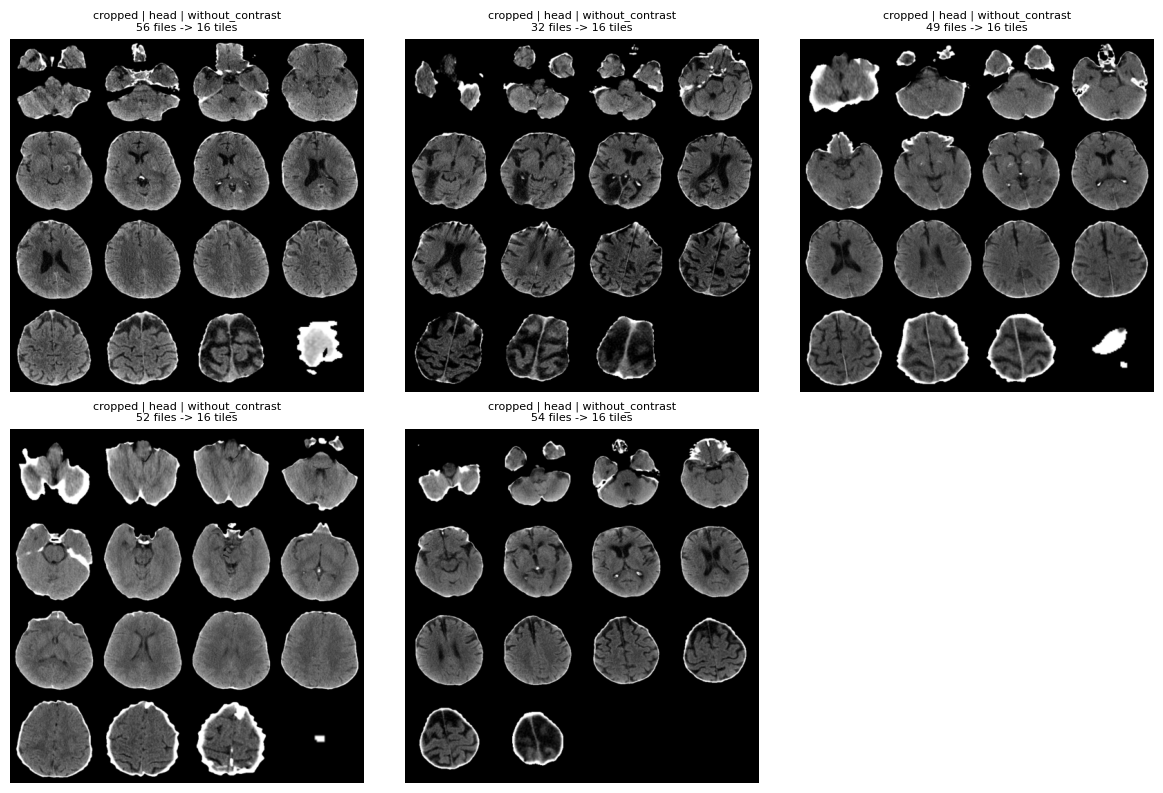

In [7]:
n = len(manifest)
cols = min(n, 3)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = [axes] if n == 1 else list(getattr(axes, "flat", [axes]))

for ax, (_, row) in zip(axes, manifest.iterrows()):
    path = REPO_ROOT / row["mosaic_path"]
    with Image.open(path) as img:
        ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"cropped | {row['body_region']} | {row['contrast_usage']}\n"
        f"{row['number_of_files']} files -> {row['sampled_slice_count']} tiles",
        fontsize=8,
    )

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
